In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
from shapely import from_wkt

def combine_districts_and_census_areas(df, district_column='codi_districte', census_column='codi_seccio_censal'):
    """Combines districts and census areas into a single column, `Seccio_Censal`."""
    df["Seccio_Censal"] = (
        (df[district_column] * 1000 ) + df[census_column]
    )

def barcelona_census_areas(url="BarcelonaCiutat_SeccionsCensals.csv"):
    """This loads the census areas as defined in a CSV file, and returns a 
    GDF with a single `Seccio_Censal` column and associated geometry.
    
    This CSV file is taken from 
    https://opendata-ajuntament.barcelona.cat/data/en/dataset/20170706-districtes-barris/resource/e16856a7-b3c0-4c32-a468-cc190cbbf7a9
    where it is described as "Detail of administrative units of the city of Barcelona : districts, neighbourhoods, Interés area, basic statistical areas (AEB) and census areas"

    The `Seccio_Censal` column is the combination of the `codi_districte` and `codi_seccio_censal`. Many other datasets
    use this as the join key and it appears to be the combination of the district and census area columns.
    
    """
    url = "BarcelonaCiutat_SeccionsCensals.csv"
    df = pd.read_csv(url)
    combine_districts_and_census_areas(df)
    
    df["geometry"] = df["geometria_wgs84"].apply(from_wkt)
    df = df[["Seccio_Censal","geometry"]]
    assert df["Seccio_Censal"].is_unique
    return gpd.GeoDataFrame(df,geometry="geometry",crs="EPSG:4326")


In [3]:
census_areas_gdf = barcelona_census_areas()

In [4]:
census_areas_gdf

,Seccio_Censal,geometry
0,1001,"POLYGON ((2.17575 41.37827, 2.17552 41.37865, ..."
1,1002,"POLYGON ((2.1751 41.37905, 2.1747 41.37951, 2...."
2,1003,"POLYGON ((2.1722 41.37692, 2.17206 41.37696, 2..."
3,1004,"POLYGON ((2.16962 41.37847, 2.16882 41.37784, ..."
4,1005,"POLYGON ((2.17366 41.38071, 2.1733 41.38113, 2..."
...,...,...
1063,10143,"POLYGON ((2.20926 41.42519, 2.20909 41.42534, ..."
1064,10234,"POLYGON ((2.18971 41.40755, 2.18948 41.40759, ..."
1065,10235,"POLYGON ((2.21303 41.41093, 2.2119 41.4118, 2...."
1066,10236,"POLYGON ((2.21203 41.41004, 2.21079 41.41096, ..."


In [14]:
census_areas_gdf.explore("Seccio_Censal")

In [6]:
def load_population_dataset(census_areas_gdf, year):
    """Load population of Barcelona for a particular year, and match to census area. Returns a GDF.
    
    This is based on "Population of Barcelona according to the Municipal Register of Inhabitants on January 1 of each year"
    https://opendata-ajuntament.barcelona.cat/data/en/dataset/pad_mdbas/resource/eb82adf2-a7b0-40e6-9624-b4b9eff23018.

    It is assumed data is kept locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_pad_mdbas.csv")
    df["population"] = df["Valor"].astype(float)
    df = df[["population","Seccio_Censal"]]
    return census_areas_gdf.merge(df, on="Seccio_Censal")

In [7]:
population_gdf = load_population_dataset(census_areas_gdf, 2023)
population_gdf

,Seccio_Censal,geometry,population
0,1001,"POLYGON ((2.17575 41.37827, 2.17552 41.37865, ...",1246.0
1,1002,"POLYGON ((2.1751 41.37905, 2.1747 41.37951, 2....",1238.0
2,1003,"POLYGON ((2.1722 41.37692, 2.17206 41.37696, 2...",3406.0
3,1004,"POLYGON ((2.16962 41.37847, 2.16882 41.37784, ...",2881.0
4,1005,"POLYGON ((2.17366 41.38071, 2.1733 41.38113, 2...",2294.0
...,...,...,...
1063,10143,"POLYGON ((2.20926 41.42519, 2.20909 41.42534, ...",1802.0
1064,10234,"POLYGON ((2.18971 41.40755, 2.18948 41.40759, ...",1742.0
1065,10235,"POLYGON ((2.21303 41.41093, 2.2119 41.4118, 2....",1304.0
1066,10236,"POLYGON ((2.21203 41.41004, 2.21079 41.41096, ...",1568.0


In [8]:
population_gdf.explore("population", scheme="percentiles")

In [12]:
def load_income_dataset(census_areas_gdf, year):
    """Load income of Barcelona for a particular year, and match to census area. Returns a GDF.

    This is based on "Average gross taxable income per person (€) in the city of Barcelona based 
    on Atlas de distribución de la renta de los hogares of Instituto Nacional de Estadística (INE)"
    https://opendata-ajuntament.barcelona.cat/data/en/dataset/atles-renda-bruta-per-persona/resource/e6cabd96-68d6-451b-bc9f-c2a381d733e6

    It is assumed data is kept locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_atles_renda_bruta_persona.csv")
    df["income"] = df["Import_Renda_Bruta_€"].astype(float)
    combine_districts_and_census_areas(df, district_column='Codi_Districte',census_column='Seccio_Censal')
    
    df = df[["income","Seccio_Censal"]]
    return census_areas_gdf.merge(df, on="Seccio_Censal")

In [13]:
income_gdf = load_income_dataset(census_areas_gdf, 2023)
income_gdf

,Seccio_Censal,geometry,income
0,1001,"POLYGON ((2.17575 41.37827, 2.17552 41.37865, ...",17113.0
1,1002,"POLYGON ((2.1751 41.37905, 2.1747 41.37951, 2....",13081.0
2,1003,"POLYGON ((2.1722 41.37692, 2.17206 41.37696, 2...",12707.0
3,1004,"POLYGON ((2.16962 41.37847, 2.16882 41.37784, ...",16040.0
4,1005,"POLYGON ((2.17366 41.38071, 2.1733 41.38113, 2...",13549.0
...,...,...,...
1063,10143,"POLYGON ((2.20926 41.42519, 2.20909 41.42534, ...",16307.0
1064,10234,"POLYGON ((2.18971 41.40755, 2.18948 41.40759, ...",21767.0
1065,10235,"POLYGON ((2.21303 41.41093, 2.2119 41.4118, 2....",19098.0
1066,10236,"POLYGON ((2.21203 41.41004, 2.21079 41.41096, ...",19360.0


In [15]:
income_gdf.explore("income")

In [16]:
import seaborn as sns

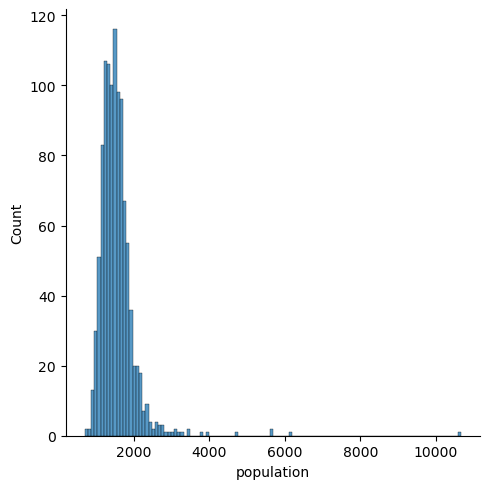

In [20]:
sns.displot(population_gdf["population"])

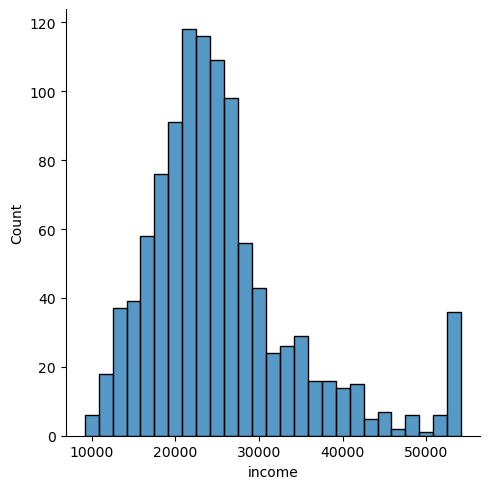

In [18]:
sns.displot(income_gdf["income"])